<a href="https://colab.research.google.com/github/Lmarra1/Actuation-manifold-from-snapshot-data/blob/main/nmpc_casadi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Nonlinear Model Predictive Control (NMPC) of the Actuated Lorenz System

### Problem Overview

This notebook implements a **Nonlinear Model Predictive Control (NMPC)** strategy to stabilize a chaotic nonlinear dynamical system: the **Lorenz system with additive control inputs**.

The objective here is to compute, at each time step, an optimal control sequence that drives the system from an arbitrary initial condition to a desired equilibrium point and stabilizes it there.

---

### Controlled Dynamical System

The controlled Lorenz system is defined as:

$$
\dot{x} = f(x) + u
$$

where:

$$
x =
\begin{bmatrix}
x_1 \\
x_2 \\
x_3
\end{bmatrix}
\quad , \quad
u =
\begin{bmatrix}
u_1 \\
u_2 \\
u_3
\end{bmatrix}
$$

and the nonlinear vector field is:

$$
f(x) =
\begin{bmatrix}
\sigma (x_2 - x_1) \\
x_1 (\rho - x_3) - x_2 \\
x_1 x_2 - \beta x_3
\end{bmatrix}
$$

The parameters are selected in the chaotic regime:

- $\sigma = 10$  
- $\rho = 28$  
- $\beta = 8/3$  

The control input acts directly on each state equation.

---

### Control Objective

The goal is to stabilize the system at the target ($x^*$), represented by one of its unstable equilibrium points:

$$
E_0 =
\begin{bmatrix}
0 \\ 0 \\ 0
\end{bmatrix}
\qquad
E_1 =
\begin{bmatrix}
\sqrt{\beta(\rho-1)} \\
\sqrt{\beta(\rho-1)} \\
\rho - 1
\end{bmatrix}
\qquad
E_2 =
\begin{bmatrix}
-\sqrt{\beta(\rho-1)} \\
-\sqrt{\beta(\rho-1)} \\
\rho - 1
\end{bmatrix}
$$


---

### Optimization Problem

The NMPC problem minimizes the following objective:

$$
J =
\sum_{k=0}^{N-1}
(x_k - x^*)^T Q (x_k - x^*)
+
u_k^T R u_k
+
(x_N - x^*)^T Q_f (x_N - x^*)
$$

subject to:

**System dynamics (discretized with RK4):**

$$
x_{k+1} = \mathrm{RK4}(x_k, u_k)
$$

**Control constraints:**

$$
u_{\min} \le u_k \le u_{\max}
$$

**Initial condition (measured state feedback):**

$$
x_0 = x_{\mathrm{current}}
$$

---

In [ ]:
# ---------------------------------------------------------
# 0. CASADI INSTALLATION
# ---------------------------------------------------------
!pip -q install casadi

Starting Simulation...


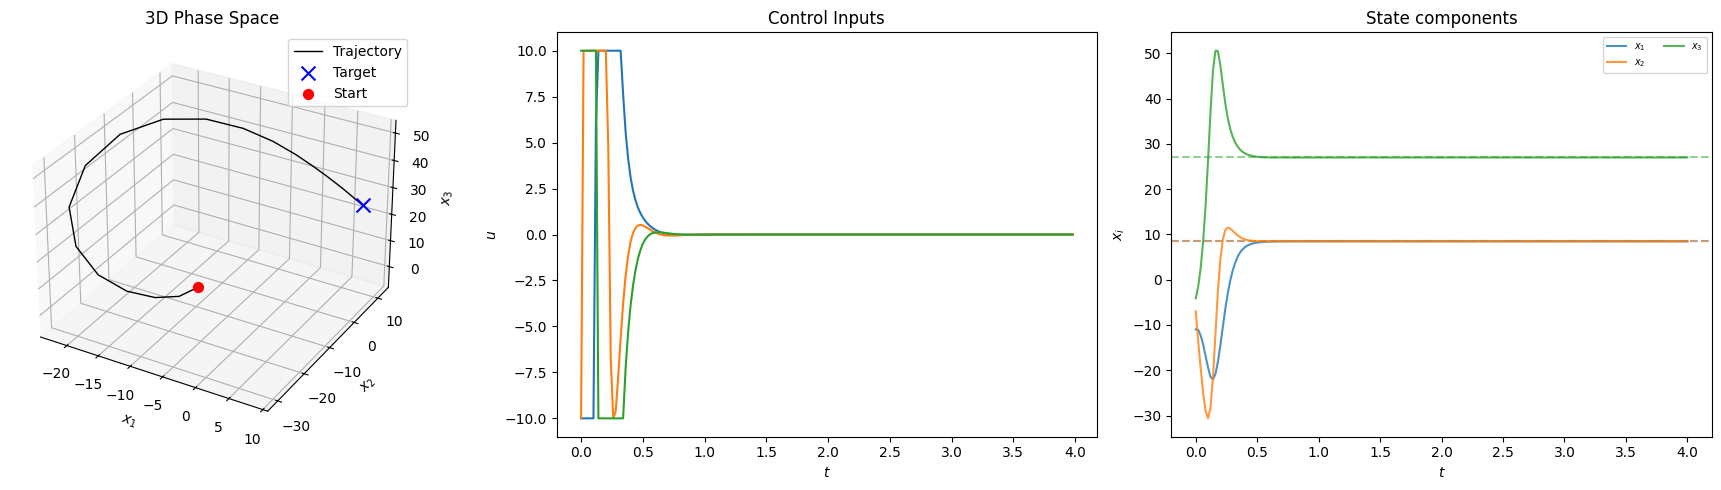

In [72]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. PARAMETERS & SYSTEM DEFINITION
# ---------------------------------------------------------
nx = 3   # State dimension (x, y, z)
nu = 3   # Control dimension (u1, u2, u3)

# Lorenz physical constants (Chaotic regime)
sigma = 10.0
rho   = 28.0
beta  = 8.0/3.0
dt    = 0.02  # Integration time step
N     = 50    # Prediction horizon (1.0 second look-ahead)


def lorenz_vector_field(x, u):
    """Defines the ODEs for the actuated Lorenz system."""
    x1, x2, x3 = x[0], x[1], x[2]
    # Natural dynamics
    f = ca.vertcat(
        sigma*(x2 - x1),
        x1*(rho - x3) - x2,
        x1*x2 - beta*x3
    )
    return f + u


# CasADi function for the model
x_sx = ca.SX.sym("x", nx)
u_sx = ca.SX.sym("u", nu)
f_model = ca.Function("f_model", [x_sx, u_sx], [lorenz_vector_field(x_sx, u_sx)])

def rk4_step(f, x, u, dt):
    """Runge-Kutta 4th order integration step."""
    k1 = f(x, u)
    k2 = f(x + dt/2 * k1, u)
    k3 = f(x + dt/2 * k2, u)
    k4 = f(x + dt * k3, u)
    return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)


# ---------------------------------------------------------
# 2. SETPOINTS & COST MATRICES
# ---------------------------------------------------------
# Calculate Fixed Points (Equilibria)
E_0    = ca.DM([np.sqrt(beta*(rho-1)), np.sqrt(beta*(rho-1)), rho-1])
E_1    = ca.DM([np.sqrt(beta*(rho-1)), np.sqrt(beta*(rho-1)), rho-1])
E_2    = ca.DM([-np.sqrt(beta*(rho-1)), -np.sqrt(beta*(rho-1)), rho-1])
x_star = E_0

# Weighting Matrices
Q  = ca.diag(ca.DM([1.0, 1.0, 1.0]))      # State error penalty
R_u = ca.diag(ca.DM([0.01, 0.01, 0.01]))  # Control effort penalty
Qf = Q                                    # Terminal cost

# Input constraints
umin = [-10.0, -10.0, -10.0]
umax = [10.0, 10.0, 10.0]



# ---------------------------------------------------------
# 3. NMPC OPTIMIZATION PROBLEM
# ---------------------------------------------------------
opti = ca.Opti()

X = opti.variable(nx, N+1)  # Decision variables: States
U = opti.variable(nu, N)    # Decision variables: Controls
X0 = opti.parameter(nx)     # Parameter: Current state
XSTAR = opti.parameter(nx)  # Parameter: Target state

# Construct Cost Function
obj = 0
for k in range(N):
    err = X[:, k] - XSTAR
    obj += ca.mtimes([err.T, Q, err]) + ca.mtimes([U[:, k].T, R_u, U[:, k]])
# Add Terminal Cost
err_N = X[:, N] - XSTAR
obj += ca.mtimes([err_N.T, Qf, err_N])
opti.minimize(obj)

# Constraints: Dynamics & Control Bounds
opti.subject_to(X[:, 0] == X0)
for k in range(N):
    opti.subject_to(X[:, k+1] == rk4_step(f_model, X[:, k], U[:, k], dt))
    opti.subject_to(opti.bounded(umin, U[:, k], umax))

# Solver Options (IPOPT)
opts = {
    "print_time": 0,
    "ipopt.print_level": 0,
    "ipopt.sb": "yes",
    "ipopt.max_iter": 1000
}

opti.solver("ipopt", opts)

# ---------------------------------------------------------
# 4. CLOSED-LOOP SIMULATION
# ---------------------------------------------------------
T_sim = 4.0
K_sim = int(T_sim / dt)
xk = np.random.uniform(-20, 20, size=3) # Random Initial Condition

# Logging Arrays
X_log = np.zeros((K_sim+1, nx))
U_log = np.zeros((K_sim, nu))
t_log = np.zeros((K_sim+1))
X_log[0, :] = xk
t_log[0]    = 0


# Set target
opti.set_value(XSTAR, x_star)

print("Starting Simulation...")
for k in range(K_sim):

    # Set IC
    opti.set_value(X0, xk)

    try:
        sol = opti.solve()
        uk = sol.value(U[:, 0]) # Extract first optimal control

        # Warm-start for next iteration (shifting window)
        opti.set_initial(U, np.hstack([sol.value(U)[:, 1:], sol.value(U)[:, -1:]]))
        opti.set_initial(X, np.hstack([sol.value(X)[:, 1:], sol.value(X)[:, -1:]]))

    except:
        uk = np.zeros(nu)

    # Apply control to system
    xk = rk4_step(f_model, xk, uk, dt).full().flatten()
    X_log[k+1, :] = xk
    U_log[k, :] = uk
    t_log[k+1] = t_log[k] + dt

# ---------------------------------------------------------
# 5. VISUALIZATION
# ---------------------------------------------------------
fig = plt.figure(figsize=(18, 5))

# Plot 1: 3D Trajectory
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(X_log[:, 0], X_log[:, 1], X_log[:, 2], color='black', lw=1, label='Trajectory')
ax1.scatter(*x_star.full().flatten(), color='blue', marker='x', s=100, label='Target')
ax1.scatter(*X_log[0,:], color='red', marker='o', s=50, label='Start')
ax1.set_title("3D Phase Space")
ax1.set_xlabel("$x_1$")
ax1.set_ylabel("$x_2$")
ax1.set_zlabel("$x_3$")
ax1.legend()

# Plot 2: Control Inputs
ax2 = fig.add_subplot(132)
ax2.plot(t_log[:-1], U_log)
ax2.set_title("Control Inputs")
ax2.set_xlabel("$t$")
ax2.set_ylabel("$u$")

# Plot 3: States vs Targets
ax3 = fig.add_subplot(133)
target = x_star.full().flatten()
for i in range(nx):
    ax3.plot(t_log, X_log[:, i], label=f'$x_{i+1}$', alpha=0.8)
    ax3.axhline(y=target[i], color=f'C{i}', linestyle='--', alpha=0.5)
ax3.set_title("State components")
ax3.set_xlabel("$t$")
ax3.set_ylabel("$x_i$")

ax3.legend(ncol=2, fontsize='x-small')

plt.tight_layout()
plt.show()
